# 05A - Bounds stress test errors analysis 

We notice that as k_Csys approache sthe 0.98 mark, the system crashes

In [2]:
import pandas as pd

df = pd.read_csv("../01_Data/simulation_results/pediatric_dcm_patient_01/bounds_stress_test/pediatric_dcm_patient_01_bounds_stress_test_results_factor_gt1_to_2.csv")

tunables = [
    "expansion_factor",
    "k_Vtot",
    "k_Vsys",
    "k_Vusv_sys",
    "k_Vusv_sys_ven",
    "k_Vusv_pulm_ven",
    "k_Ctot",
    "k_Csys",
    "k_Rsysven",
    "k_Rpulmart",
    "k_ESP_LV",
    "k_ESP_RV",
]

failed = df[df["simulation_status"] == "failed"]
success = df[df["simulation_status"] == "success"]

print("Total:", len(df))
print("Success:", len(success))
print("Failed:", len(failed))
print("Failure rate:", len(failed) / len(df) * 100)

print("\nFailed cases:")
print(failed[["simulation_id"] + tunables])

print("\nMean tunables: success vs failed")
print(df.groupby("simulation_status")[tunables].mean())

print("\nMin/max tunables in failed cases")
print(failed[tunables].describe().T)

Total: 120
Success: 114
Failed: 6
Failure rate: 5.0

Failed cases:
     simulation_id  expansion_factor     k_Vtot    k_Vsys  k_Vusv_sys  \
45              75              1.50  92.734284  0.794658    0.722272   
53              83              1.50  77.041836  0.824232    0.922446   
56              86              1.50  86.107101  0.812909    0.913973   
68              98              1.75  74.431614  0.897333    0.695725   
74             104              1.75  92.486336  0.744776    0.734286   
116            146              2.00  83.666118  0.794727    0.917058   

     k_Vusv_sys_ven  k_Vusv_pulm_ven    k_Ctot    k_Csys  k_Rsysven  \
45         0.899729         0.969686  1.879772  0.981265   0.050215   
53         0.925455         0.806697  1.557356  0.975917   0.070232   
56         0.934310         0.765185  2.618310  0.995412   0.056015   
68         0.998218         0.905763  1.616570  0.988199   0.065044   
74         0.896070         0.836511  2.369735  0.990829   0.07585

In [3]:
print("Successful k_Csys:")
print(success["k_Csys"].describe())

print("\nFailed k_Csys:")
print(failed["k_Csys"].describe())

Successful k_Csys:
count    114.000000
mean       0.832354
std        0.085668
min        0.653639
25%        0.764499
50%        0.832859
75%        0.902904
max        0.980104
Name: k_Csys, dtype: float64

Failed k_Csys:
count    6.000000
mean     0.987201
std      0.007258
min      0.975917
25%      0.982999
50%      0.989514
75%      0.991396
max      0.995412
Name: k_Csys, dtype: float64


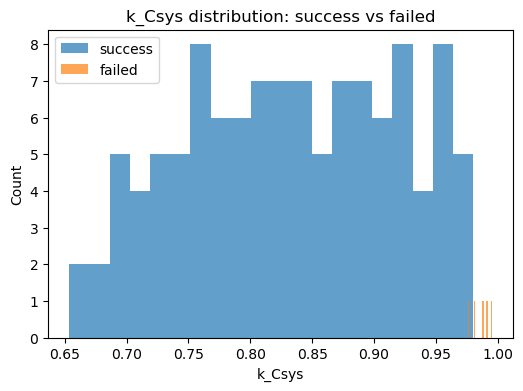

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(success["k_Csys"], bins=20, alpha=0.7, label="success")
plt.hist(failed["k_Csys"], bins=20, alpha=0.7, label="failed")
plt.xlabel("k_Csys")
plt.ylabel("Count")
plt.title("k_Csys distribution: success vs failed")
plt.legend()
plt.show()